In [1]:
# https://youtu.be/tepxdcepTbY
"""
@author: Sreenivas Bhattiprolu

Code tested on Tensorflow: 2.2.0
    Keras: 2.4.3

dataset: https://finance.yahoo.com/quote/GE/history/
Also try S&P: https://finance.yahoo.com/quote/%5EGSPC/history?p=%5EGSPC
"""

import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [3]:

#from datetime import datetime

#Read the csv file
df = pd.read_csv(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_24.csv')
df.head()  #7 columns, including the Date.

,time,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
0,00:00,3832.0,7.447042,276.0,446.658936,457.035217,0.519437,-1.207168,75.990444,64.934504
1,00:03,4813.0,3.767090,332.0,443.744446,454.648438,0.479802,0.747667,85.257031,74.802547
2,00:06,4659.0,12.844211,322.0,453.411041,463.106018,0.710101,0.789391,92.406796,65.063624
3,00:09,4974.0,5.534648,352.0,456.660645,467.586243,0.852614,0.513725,113.571675,59.345921
4,00:12,4597.0,6.907563,338.0,460.910156,473.031982,0.836428,0.416494,107.025891,58.658346


In [20]:

#Separate dates for future plotting
train_times = pd.to_datetime(df['time'], format='%H:%M').dt.time
print(train_times.tail(15))  #Check last few dates.

28    01:24:00
29    01:27:00
30    01:30:00
31    01:33:00
32    01:36:00
33    01:39:00
34    01:42:00
35    01:45:00
36    01:48:00
37    01:51:00
38    01:54:00
39    01:57:00
40    02:00:00
41    02:03:00
42    02:06:00
Name: time, dtype: object


In [29]:
df = df.reindex(columns=['time', 'speed', 'area', 'perimeter', 'xcentre', 'ycentre', 'eccentricity', 'orientation', 'major_axis', 'minor_axis'])
#Variables for training
cols = list(df)[1:]
#Date and volume columns are not used in training.
print(cols)  #['Open', 'High', 'Low', 'Close', 'Adj Close']

['speed', 'area', 'perimeter', 'xcentre', 'ycentre', 'eccentricity', 'orientation', 'major_axis', 'minor_axis']


In [30]:

#New dataframe with only training data - 5 columns
df_for_training = df[cols].astype(float)

# df_for_plot=df_for_training.tail(5000)
# df_for_plot.plot.line()

#LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
# normalize the dataset
scaler = StandardScaler()
scaler = scaler.fit(df_for_training)
df_for_training_scaled = scaler.transform(df_for_training)

#As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features.
#In this example, the n_features is 5. We will make timesteps = 14 (past days data used for training).

#Empty lists to be populated using formatted training data
trainX = []
trainY = []

In [31]:

n_future = 1  # Number of days we want to look into the future based on the past days.
n_past = 4  # Number of past days we want to use to predict the future.

#Reformat input data into a shape: (n_samples x timesteps x n_features)
#In my example, my df_for_training_scaled has a shape (12823, 5)
#12823 refers to the number of data points and 5 refers to the columns (multi-variables).
for i in range(n_past, len(df_for_training_scaled) - n_future + 1):
    trainX.append(df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])
    trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0])

trainX, trainY = np.array(trainX), np.array(trainY)

print('trainX shape == {}.'.format(trainX.shape))
print('trainY shape == {}.'.format(trainY.shape))

#In my case, trainX has a shape (12809, 14, 5).
#12809 because we are looking back 14 days (12823 - 14 = 12809).
#Remember that we cannot look back 14 days until we get to the 15th day.
#Also, trainY has a shape (12809, 1). Our model only predicts a single value, but
#it needs multiple variables (5 in my example) to make this prediction.
#This is why we can only predict a single day after our training, the day after where our data ends.
#To predict more days in future, we need all the 5 variables which we do not have.
#We need to predict all variables if we want to do that.

trainX shape == (39, 4, 9).
trainY shape == (39, 1).


In [32]:
trainX[0]

array([[ 0.        , -0.79918809, -0.92599488, -1.15663128, -2.37903536,
        -1.65676206, -1.20750433, -1.26165997, -0.13705324],
       [-0.67668423,  0.16531536,  0.61209831, -1.37235638, -2.51517795,
        -2.09284185,  0.91765096, -0.48013217,  1.09912415],
       [ 0.99245307,  0.01390503,  0.33743881, -0.65685299, -2.03275518,
         0.44099556,  0.96300975,  0.12286652, -0.12087827],
       [-0.35165852,  0.32360797,  1.16141731, -0.41632341, -1.77720191,
         2.00897781,  0.6633263 ,  1.90787558, -0.83713932]])

In [42]:
trainX.shape[2]

9

C:\Users\2MY\anaconda3\envs\Research\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 4, 64)          │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.2413 - val_loss: 0.4579
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8823 - val_loss: 0.4494
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0769 - val_loss: 0.4488
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.2237 - val_loss: 0.4484
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9840 - val_loss: 0.4431
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9316 - val_loss: 0.4352
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.2017 - val_loss: 0.4345
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8615 - val_loss: 0.4311
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1717 - val_loss: 0.4218
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1351 - val_loss: 0.4059
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0213 - val_loss: 0.3862
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.1441 - val_lo

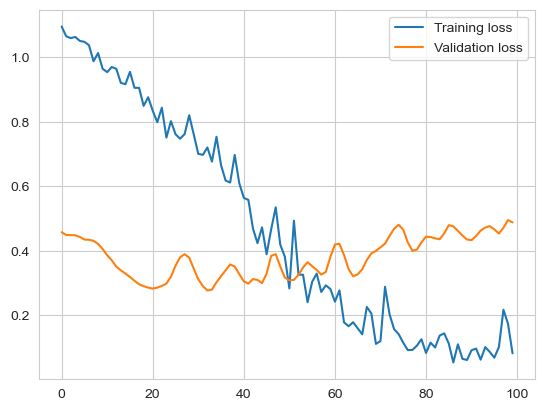

In [39]:

# define the Autoencoder model

model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(trainX.shape[1], trainX.shape[2]), return_sequences=True, stateful=False))
model.add(LSTM(32, activation='relu', return_sequences=False, stateful=False))
model.add(Dropout(0.2))
model.add(Dense(trainY.shape[1]))

model.compile(optimizer='adam', loss='mse')
model.summary()

# fit the model
history = model.fit(trainX, trainY, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:

#Predicting...
#Libraries that will help us extract only business days in the US.
#Otherwise our dates would be wrong when we look back (or forward).
# from pandas.tseries.holiday import USFederalHolidayCalendar
# from pandas.tseries.offsets import CustomBusinessDay
# 
# us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
#Remember that we can only predict one day in future as our model needs 5 variables
#as inputs for prediction. We only have all 5 variables until the last day in our dataset.
n_past = 10
n_days_for_prediction = 15  #let us predict past 15 days

predict_period_dates = pd.date_range(list(train_dates)[-n_past], periods=n_days_for_prediction, freq=us_bd).tolist()
print(predict_period_dates)

#Make prediction
prediction = model.predict(trainX[-n_days_for_prediction:])  #shape = (n, 1) where n is the n_days_for_prediction

#Perform inverse transformation to rescale back to original range
#Since we used 5 variables for transform, the inverse expects same dimensions
#Therefore, let us copy our values 5 times and discard them after inverse transform
prediction_copies = np.repeat(prediction, df_for_training.shape[1], axis=-1)
y_pred_future = scaler.inverse_transform(prediction_copies)[:, 0]

In [ ]:

# Convert timestamp to date
forecast_dates = []
for time_i in predict_period_dates:
    forecast_dates.append(time_i.date())

df_forecast = pd.DataFrame({'Date': np.array(forecast_dates), 'Open': y_pred_future})
df_forecast['Date'] = pd.to_datetime(df_forecast['Date'])

original = df[['Date', 'Open']]
original['Date'] = pd.to_datetime(original['Date'])
original = original.loc[original['Date'] >= '2020-5-1']

sns.lineplot(original['Date'], original['Open'])
sns.lineplot(df_forecast['Date'], df_forecast['Open'])


